# Multi-molecule Scaling Benchmark

This notebook compares lightweight VQE, VarQITE, and QPE runs as the chemistry problem grows.

It reports:

- qubit count by molecule
- runtime by method
- absolute error against an exact qubit-Hamiltonian diagonalization
- rough proxy metrics such as Hamiltonian term count, total QPE wires, and variational parameter count

To keep the largest example practical, LiH and BeH2 are run with explicit active spaces.

In [5]:
from __future__ import annotations

import time

import matplotlib.pyplot as plt
import numpy as np
import pennylane as qml

from common.hamiltonian import build_hamiltonian
from qite import run_qite
from qpe import run_qpe
from vqe import run_vqe

MOLECULE_SPECS = [
    {"molecule": "H2", "mapping": "jordan_wigner"},
    {
        "molecule": "LiH",
        "mapping": "jordan_wigner",
        "active_electrons": 2,
        "active_orbitals": 2,
    },
    {
        "molecule": "BeH2",
        "mapping": "jordan_wigner",
        "active_electrons": 4,
        "active_orbitals": 4,
    },
]


def timed_call(fn, /, **kwargs):
    t0 = time.perf_counter()
    result = fn(**kwargs)
    return result, time.perf_counter() - t0


def exact_ground_energy_and_size(spec):
    H, n_qubits, _ = build_hamiltonian(**spec)
    matrix = np.asarray(qml.matrix(H), dtype=complex)
    eigs = np.linalg.eigvalsh(matrix)
    return {
        "exact_ground": float(np.min(eigs).real),
        "num_qubits": int(n_qubits),
        "hamiltonian_terms": int(len(H)),
    }


baseline = [
    {**spec, **exact_ground_energy_and_size(spec)}
    for spec in MOLECULE_SPECS
]
baseline

[{'molecule': 'H2',
  'mapping': 'jordan_wigner',
  'exact_ground': -1.1372701748841751,
  'num_qubits': 4,
  'hamiltonian_terms': 15},
 {'molecule': 'LiH',
  'mapping': 'jordan_wigner',
  'active_electrons': 2,
  'active_orbitals': 2,
  'exact_ground': -7.862128847850949,
  'num_qubits': 4,
  'hamiltonian_terms': 27},
 {'molecule': 'BeH2',
  'mapping': 'jordan_wigner',
  'active_electrons': 4,
  'active_orbitals': 4,
  'exact_ground': -15.56599068920284,
  'num_qubits': 8,
  'hamiltonian_terms': 61}]

In [ ]:
rows = []

for spec in baseline:
    shared = {
        key: spec[key]
        for key in ["molecule", "mapping", "active_electrons", "active_orbitals"]
        if key in spec
    }
    exact_ground = spec["exact_ground"]

    vqe_res, runtime_s = timed_call(
        run_vqe,
        **shared,
        ansatz_name="UCCSD",
        optimizer_name="Adam",
        steps=75,
        stepsize=0.2,
        plot=False,
        seed=0,
        force=False,
    )
    rows.append(
        {
            "molecule": spec["molecule"],
            "method": "VQE",
            "num_qubits": spec["num_qubits"],
            "runtime_s": runtime_s,
            "energy": float(vqe_res["energy"]),
            "abs_error": abs(float(vqe_res["energy"]) - exact_ground),
            "param_count": int(np.asarray(vqe_res["final_params"]).size),
            "hamiltonian_terms": spec["hamiltonian_terms"],
            "proxy": int(np.asarray(vqe_res["final_params"]).size),
        }
    )

    qite_res, runtime_s = timed_call(
        run_qite,
        **shared,
        ansatz_name="UCCSD",
        steps=50,
        dtau=0.2,
        plot=False,
        show=False,
        seed=0,
        force=False,
    )
    rows.append(
        {
            "molecule": spec["molecule"],
            "method": "VarQITE",
            "num_qubits": spec["num_qubits"],
            "runtime_s": runtime_s,
            "energy": float(qite_res["energy"]),
            "abs_error": abs(float(qite_res["energy"]) - exact_ground),
            "param_count": int(np.asarray(qite_res["final_params"]).size),
            "hamiltonian_terms": spec["hamiltonian_terms"],
            "proxy": int(np.asarray(qite_res["final_params"]).size),
        }
    )

    qpe_ancillas = 4 if spec["num_qubits"] <= 4 else 8
    qpe_res, runtime_s = timed_call(
        run_qpe,
        **shared,
        n_ancilla=qpe_ancillas,
        t=1.0,
        trotter_steps=2,
        shots=1000,
        plot=False,
        seed=0,
        force=False,
    )
    rows.append(
        {
            "molecule": spec["molecule"],
            "method": "QPE",
            "num_qubits": spec["num_qubits"],
            "runtime_s": runtime_s,
            "energy": float(qpe_res["energy"]),
            "abs_error": abs(float(qpe_res["energy"]) - exact_ground),
            "param_count": 0,
            "hamiltonian_terms": spec["hamiltonian_terms"],
            "proxy": int(spec["num_qubits"] + qpe_ancillas),
        }
    )

rows

Step 01/75: E = -1.116684 Ha
Step 02/75: E = -1.136994 Ha
Step 03/75: E = -1.131007 Ha
Step 04/75: E = -1.122700 Ha
Step 05/75: E = -1.130115 Ha
Step 06/75: E = -1.133031 Ha
Step 07/75: E = -1.134496 Ha
Step 08/75: E = -1.134652 Ha
Step 09/75: E = -1.132102 Ha
Step 10/75: E = -1.130839 Ha
Step 11/75: E = -1.133769 Ha
Step 12/75: E = -1.136856 Ha
Step 13/75: E = -1.136817 Ha
Step 14/75: E = -1.134837 Ha
Step 15/75: E = -1.133732 Ha
Step 16/75: E = -1.134458 Ha
Step 17/75: E = -1.135957 Ha
Step 18/75: E = -1.136742 Ha
Step 19/75: E = -1.136508 Ha
Step 20/75: E = -1.136055 Ha
Step 21/75: E = -1.135899 Ha
Step 22/75: E = -1.135938 Ha
Step 23/75: E = -1.136174 Ha
Step 24/75: E = -1.136688 Ha
Step 25/75: E = -1.137068 Ha
Step 26/75: E = -1.136886 Ha
Step 27/75: E = -1.136406 Ha
Step 28/75: E = -1.136270 Ha
Step 29/75: E = -1.136684 Ha
Step 30/75: E = -1.137181 Ha
Step 31/75: E = -1.137213 Ha
Step 32/75: E = -1.136850 Ha
Step 33/75: E = -1.136654 Ha
Step 34/75: E = -1.136858 Ha
Step 35/75: E 

[{'molecule': 'H2',
  'method': 'VQE',
  'num_qubits': 4,
  'runtime_s': 3.4823177039997972,
  'energy': -1.1372675666881946,
  'abs_error': 2.6081959805246413e-06,
  'param_count': 3,
  'hamiltonian_terms': 15,
  'proxy': 3},
 {'molecule': 'H2',
  'method': 'VarQITE',
  'num_qubits': 4,
  'runtime_s': 3.1358375429999796,
  'energy': -1.1372701748841756,
  'abs_error': 4.440892098500626e-16,
  'param_count': 3,
  'hamiltonian_terms': 15,
  'proxy': 3},
 {'molecule': 'H2',
  'method': 'QPE',
  'num_qubits': 4,
  'runtime_s': 0.4293136759997651,
  'energy': -1.1780972450961724,
  'abs_error': 0.040827070211997274,
  'param_count': 0,
  'hamiltonian_terms': 15,
  'proxy': 8},
 {'molecule': 'LiH',
  'method': 'VQE',
  'num_qubits': 4,
  'runtime_s': 6.855762634999337,
  'energy': -7.8621273888703485,
  'abs_error': 1.4589806003328931e-06,
  'param_count': 3,
  'hamiltonian_terms': 27,
  'proxy': 3},
 {'molecule': 'LiH',
  'method': 'VarQITE',
  'num_qubits': 4,
  'runtime_s': 6.13632343599

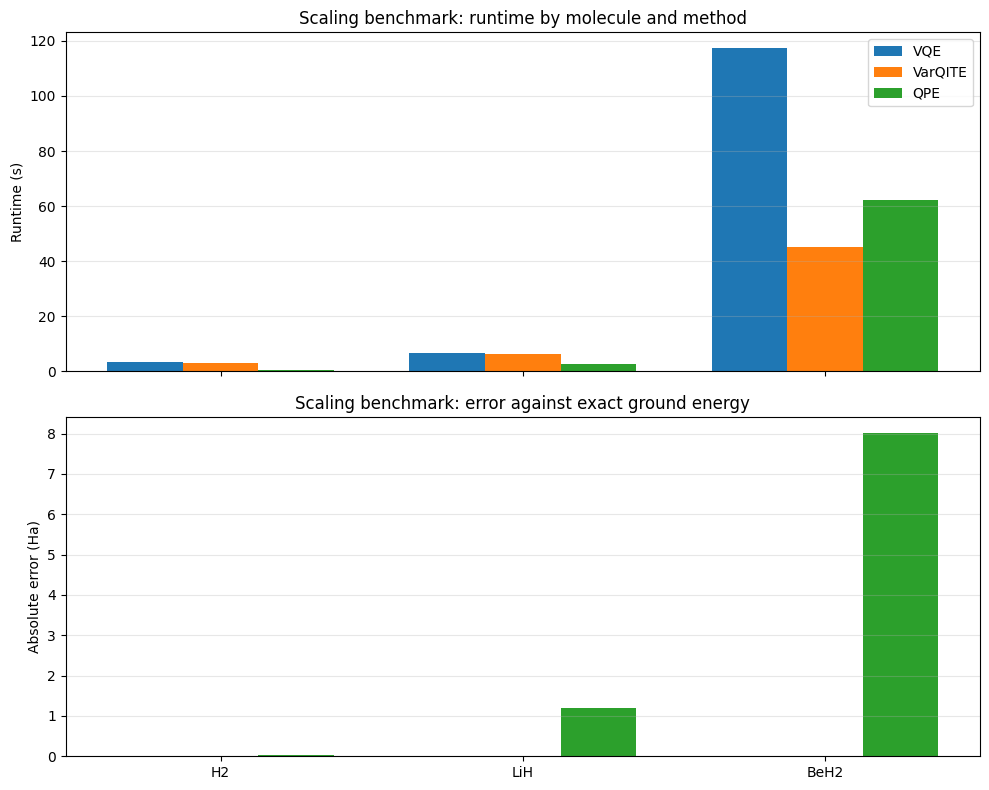

In [7]:
molecules = [spec["molecule"] for spec in baseline]
methods = ["VQE", "VarQITE", "QPE"]

runtime_map = {
    (row["molecule"], row["method"]): row["runtime_s"]
    for row in rows
}
error_map = {
    (row["molecule"], row["method"]): row["abs_error"]
    for row in rows
}

x = np.arange(len(molecules))
width = 0.25

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
for idx, method in enumerate(methods):
    runtimes = [runtime_map[(mol, method)] for mol in molecules]
    errors = [error_map[(mol, method)] for mol in molecules]
    ax1.bar(x + (idx - 1) * width, runtimes, width=width, label=method)
    ax2.bar(x + (idx - 1) * width, errors, width=width, label=method)

ax1.set_ylabel("Runtime (s)")
ax1.set_title("Scaling benchmark: runtime by molecule and method")
ax1.grid(axis="y", alpha=0.3)
ax1.legend()

ax2.set_ylabel("Absolute error (Ha)")
ax2.set_title("Scaling benchmark: error against exact ground energy")
ax2.set_xticks(x)
ax2.set_xticklabels(molecules)
ax2.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

In [8]:
baseline, rows

([{'molecule': 'H2',
   'mapping': 'jordan_wigner',
   'exact_ground': -1.1372701748841751,
   'num_qubits': 4,
   'hamiltonian_terms': 15},
  {'molecule': 'LiH',
   'mapping': 'jordan_wigner',
   'active_electrons': 2,
   'active_orbitals': 2,
   'exact_ground': -7.862128847850949,
   'num_qubits': 4,
   'hamiltonian_terms': 27},
  {'molecule': 'BeH2',
   'mapping': 'jordan_wigner',
   'active_electrons': 4,
   'active_orbitals': 4,
   'exact_ground': -15.56599068920284,
   'num_qubits': 8,
   'hamiltonian_terms': 61}],
 [{'molecule': 'H2',
   'method': 'VQE',
   'num_qubits': 4,
   'runtime_s': 3.4823177039997972,
   'energy': -1.1372675666881946,
   'abs_error': 2.6081959805246413e-06,
   'param_count': 3,
   'hamiltonian_terms': 15,
   'proxy': 3},
  {'molecule': 'H2',
   'method': 'VarQITE',
   'num_qubits': 4,
   'runtime_s': 3.1358375429999796,
   'energy': -1.1372701748841756,
   'abs_error': 4.440892098500626e-16,
   'param_count': 3,
   'hamiltonian_terms': 15,
   'proxy': 3}